In [3]:
import os
import torch
import torch.nn as nn

from torchvision.datasets import Flowers102
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset

import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchvision.utils import save_image
import pandas as pd

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/WGAN_GP_Flowers102'
os.makedirs(DRIVE_PATH, exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/output/wgan-gp-images", exist_ok=True)
os.makedirs(f"{DRIVE_PATH}/output/wgan-gp-ckpts", exist_ok=True)

print(f"Google Drive mounted at: {DRIVE_PATH}")

In [5]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ADD YOUR HYPERPARAMS HERE!

LATENT_DIM = 100
IMG_SHAPE = (3, 64, 64) # (c, h, w)
BATCH_SIZE = 128
LR_G = 0.0002
LR_D = 0.0001
b1 = 0.5
b2 = 0.999
EPOCHS = 100

# WGAN-GP specific parameters
LAMBDA_GP = 10  # Gradient penalty coefficient
N_CRITIC = 5    # Number of critic updates per generator update

SAMPLE_INTERVAL = 100  # generate validation samples every N steps
CKPT_INTERVAL = 5      # save ckpt every M epochs

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(LATENT_DIM, 1024 * 4 * 4) 

        self.conv = nn.Sequential(
        
            nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.fc(z)
        # Reshape in 4D
        out = out.view(out.shape[0], 1024, 4, 4)
        out = self.conv(out)
        return out

In [7]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 -> 16x16
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128, affine=True), 
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 -> 8x8
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 4x4
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.InstanceNorm2d(512, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc = nn.Linear(512 * 4 * 4, 1)

    def forward(self, x):
        out = self.conv(x)
        out = out.flatten(1)
        return self.fc(out)

In [8]:
device = torch.device(DEVICE)

# Initialize generator and critic
generator = Generator().to(device)
critic = Critic().to(device)

print(f"Generator:\n{generator}")
print(f"\nCritic:\n{critic}")

In [9]:
# DEFINE THE TRANSFORMS TO APPLY TO IMAGES

transform = transforms.Compose([
    transforms.Resize(64),        
    transforms.CenterCrop(64),    
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# DEFINE THE DATASET CLASSES
train_set = Flowers102(
    root='./data',
    split='train',
    transform=transform,
    download=True
)
val_set = Flowers102(
    root='./data',
    split='val',
    transform=transform,
    download=True
)
test_set = Flowers102(
    root='./data',
    split='test',
    transform=transform,
    download=True
)

# CONCAT THE 3 PROVIDED SPLITS TO GET A LARGER TRAINING SET
full_set = torch.utils.data.ConcatDataset([train_set, val_set, test_set])

print("Train set: ", len(train_set))
print("Validation set: ", len(val_set))
print("Test set: ", len(test_set))
print("Full set: ", len(full_set))

In [10]:
# DEFINE DATALOADERS

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)
val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

full_loader = torch.utils.data.DataLoader(
    full_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

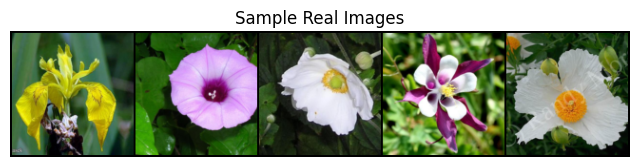

In [11]:
# Visualize a batch of real images
images, labels = next(iter(train_loader))

# make a grid
grid = vutils.make_grid(images[:5], nrow=5, normalize=True)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Sample Real Images")
plt.show()

In [12]:
# GRADIENT PENALTY FUNCTION FOR WGAN-GP
def gradient_penalty(critic, real_images, fake_images, device):
    """
    Calculate the gradient penalty for WGAN-GP
    
    Args:
        critic: The critic network
        real_images: Batch of real images
        fake_images: Batch of fake images
        device: Device to compute on
        
    Returns:
        gp: The gradient penalty value
    """
    batch_size = real_images.size(0)
    
    # Generate random interpolation weights
    alpha = torch.rand((batch_size, 1, 1, 1), device=device, requires_grad=True)
    
    # Interpolate between real and fake images
    interpolates = (alpha * real_images + (1 - alpha) * fake_images).requires_grad_(True)
    
    # Get critic output for interpolated images
    d_interpolates = critic(interpolates)
    
    # Get gradients with respect to interpolated images
    fake = torch.ones((batch_size, 1), device=device, requires_grad=True)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    
    # Reshape gradients
    gradients = gradients.view(batch_size, -1)
    
    # Calculate gradient penalty
    gradient_penalty_val = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    
    return gradient_penalty_val

In [13]:
# Optimizers
optimizer_G = torch.optim.Adam(
    generator.parameters(),
    lr=LR_G,
    betas=(b1, b2)
)
optimizer_C = torch.optim.Adam(
    critic.parameters(),
    lr=LR_D,  
    betas=(b1, b2)
)

In [ ]:
# DEFINE THE TRAINING LOOP FOR WGAN-GP

# Sample fixed noise as generator input - to visualize training progress
fixed_z = torch.randn(25, LATENT_DIM, device=device)

g_losses = []
c_losses = []
gp_losses = []
wasserstein_distances = []


for epoch in range(EPOCHS):
    for i, (real_images, _) in enumerate(full_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # ---------------------
        #  Train Critic
        # ---------------------
        
        
        for _ in range(N_CRITIC):
            optimizer_C.zero_grad()
            
            # Real images
            real_output = critic(real_images)
            
            # Fake images
            z = torch.randn(batch_size, LATENT_DIM, device=device)
            fake_images = generator(z).detach()
            fake_output = critic(fake_images)
            
            # Wasserstein distance
            wasserstein_dist = real_output.mean() - fake_output.mean()
            
            # Critic loss (negative Wasserstein distance to maximize)
            c_loss = -wasserstein_dist
            
            # Gradient penalty
            gp = gradient_penalty(critic, real_images, fake_images, device)
            
            # Total critic loss
            c_loss_total = c_loss + LAMBDA_GP * gp
            
            c_loss_total.backward()
            optimizer_C.step()
            
            # Log losses for first batch only
            if _ == 0:  
                c_losses.append(c_loss.item())
                gp_losses.append(gp.item())
                wasserstein_distances.append(wasserstein_dist.item())
        
        # -----------------
        #  Train Generator
        # -----------------
        
        optimizer_G.zero_grad()
        z = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_images = generator(z)
        fake_output = critic(fake_images)
        
        # Generator loss 
        g_loss = -fake_output.mean()
        g_loss.backward()
        optimizer_G.step()
        
        g_losses.append(g_loss.item())
        
        if i % 10 == 0:
            print(
                f"[Epoch {epoch}/{EPOCHS}] [Batch {i}/{len(full_loader)}] "
                f"[C loss: {c_loss.item():.4f}] [G loss: {g_loss.item():.4f}] "
                f"[GP: {gp.item():.4f}] [W-dist: {wasserstein_dist.item():.4f}]"
            )

        steps = epoch * len(full_loader) + i
        if steps % SAMPLE_INTERVAL == 0:
            # Generate a batch of images
            with torch.no_grad():
                fake_images = generator(fixed_z)
            drive_path = f"{DRIVE_PATH}/output/wgan-gp-images/step-{steps}.jpg"
            save_image(fake_images.data[:25], drive_path, nrow=5, normalize=True)

    if ((epoch+1) % CKPT_INTERVAL) == 0:
        torch.save(generator.state_dict(), f"{DRIVE_PATH}/output/wgan-gp-ckpts/generator_weights_ep-{epoch+1}.pth")
        torch.save(critic.state_dict(), f"{DRIVE_PATH}/output/wgan-gp-ckpts/critic_weights_ep-{epoch+1}.pth")
        
        metrics_dir = f"{DRIVE_PATH}/output/wgan-gp-ckpts/metrics"
        os.makedirs(metrics_dir, exist_ok=True)
        metrics_df = pd.DataFrame({
            'g_losses': g_losses,
            'c_losses': c_losses,
            'gp_losses': gp_losses,
            'wasserstein_distances': wasserstein_distances
        })
        csv_save_path = f"{metrics_dir}/metrics.csv"
        metrics_df.to_csv(csv_save_path, index=False)

print("\nTraining completed")

In [41]:
# PLOT WGAN-GP LOSSES

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

csv_path = f"{DRIVE_PATH}/output/wgan-gp-ckpts/metrics/metrics.csv" 
df = pd.read_csv(csv_path)

# Generator Loss
axes[0, 0].plot(df['g_losses'], label='Generator Loss', color='blue')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Generator Loss')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Critic Loss
axes[0, 1].plot(df['c_losses'], label='Critic Loss', color='red')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Critic Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Gradient Penalty
axes[1, 0].plot(df['gp_losses'], label='Gradient Penalty', color='green')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('GP Loss')
axes[1, 0].set_title('Gradient Penalty')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Wasserstein Distance
axes[1, 1].plot(df['wasserstein_distances'], label='Wasserstein Distance', color='purple')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('W-distance')
axes[1, 1].set_title('Wasserstein Distance (Estimate)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/losses_wgan_gp.jpg', dpi=150)
plt.show()

In [45]:
from torchvision.utils import make_grid


epochs_to_compare = [0, 10, 30, 50, 70, 100]
num_samples = 8
nrow = 8

fig, axes = plt.subplots(len(epochs_to_compare) + 1, 1, figsize=(15, 3 * (len(epochs_to_compare) + 1)))

# --- REAL IMAGES ---
real_batch, _ = next(iter(full_loader))
real_grid = make_grid(real_batch[:num_samples], nrow=nrow, normalize=True)
axes[0].imshow(real_grid.permute(1, 2, 0).cpu())
axes[0].set_title("Real images from dataset", fontsize=14, fontweight='bold')
axes[0].axis("off")

# --- FIXED NOISE ---
fixed_z_path = "/content/drive/MyDrive/DCGAN_Flowers102/output/fixed_z.pt"
if os.path.exists(fixed_z_path):
    fixed_z = torch.load(fixed_z_path, map_location=device)
    if fixed_z.dim() == 4:
        fixed_z = fixed_z.view(fixed_z.size(0), -1)
else:
    fixed_z = torch.randn(25, 100, device=device)

# --- GENERATED IMAGES PER EPOCH ---
for i, ep in enumerate(epochs_to_compare):
    idx = i + 1
    path = f"{DRIVE_PATH}/output/wgan-gp-ckpts/generator_weights_ep-{ep}.pth"
    
 
    gen_model = Generator().to(device)
    
    if ep == 0:
        
        title = "Epoch 0 (Initial Random Noise)"
        found = True
    elif os.path.exists(path):
        
        gen_model.load_state_dict(torch.load(path, map_location=device))
        title = f"Epoch Model {ep}"
        found = True
    else:
        found = False

    if found:
        gen_model.eval()
        with torch.no_grad():
            z = fixed_z[:num_samples]
            if z.dim() != 2:
                z = z.view(z.size(0), -1)
            fake_batch = gen_model(z)
        
        fake_grid = make_grid(fake_batch.cpu(), nrow=nrow, normalize=True)
        axes[idx].imshow(fake_grid.permute(1, 2, 0))
        axes[idx].set_title(title, fontsize=12)
    else:
        axes[idx].text(0.5, 0.5, f"Checkpoint Ep {ep} not available", ha='center', va='center')
    
    axes[idx].axis("off")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("WGAN-GP: Quality Progression ", fontsize=18)
plt.savefig(f"{DRIVE_PATH}/wgan_evolution_complete.jpg", bbox_inches='tight', dpi=150)
plt.show()